# 04 — Interpretability & Business Insights
### Turning the model into decisions

**Why are we doing this?** A PR-AUC number is not a deliverable a publisher
or acquisitions editor can act on. This notebook translates the model's
behavior into concrete, checkable statements about *which kinds of books
are predicted to gain reader engagement, and why* — the "market
intelligence" the project name promises.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.config import load_config
from src.features import NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_ENCODED_SOURCE_COLS

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                      'axes.spines.top': False, 'axes.spines.right': False})

cfg = load_config()
model = joblib.load(cfg['paths']['model_dir'] + 'engagement_model.joblib')
test_df = pd.read_parquet(cfg['paths']['test_data'])
with open(cfg['paths']['reports_dir'] + 'test_metrics.json') as f:
    test_metrics = json.load(f)
print('Loaded model:', type(model.classifier).__name__)
print('Test PR-AUC:', round(test_metrics['average_precision'], 4))


Loaded model: XGBClassifier
Test PR-AUC: 0.7461


## 1. SHAP: global feature effects on the transformed feature space

In [2]:
X_test_transformed = model._transform_features(test_df)
feature_names = model.feature_names_

explainer = shap.TreeExplainer(model.classifier)
shap_values = explainer.shap_values(X_test_transformed)

# shap_values can be (n, k) for binary xgboost or a list; normalize to array
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print('SHAP values shape:', sv.shape, '| features:', len(feature_names))


SHAP values shape: (2225, 31) | features: 31


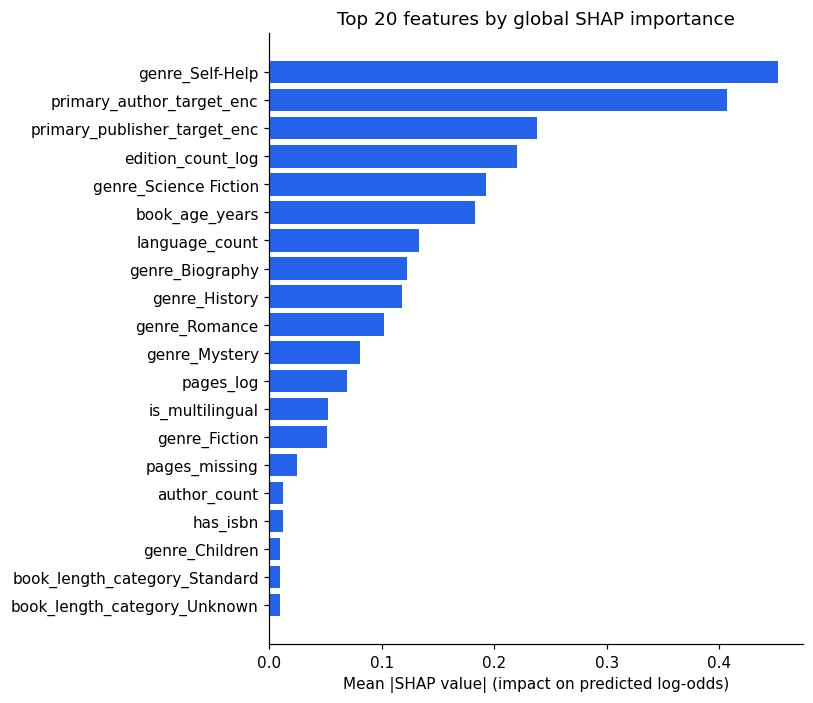

In [3]:
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=feature_names).sort_values(ascending=False)
top20 = mean_abs_shap.head(20)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.barh(top20.index[::-1], top20.values[::-1], color='#2563eb')
ax.set_xlabel('Mean |SHAP value| (impact on predicted log-odds)')
ax.set_title('Top 20 features by global SHAP importance')
fig.tight_layout()
fig.savefig(cfg['paths']['figures_dir'] + 'shap_global_importance.png', bbox_inches='tight')
plt.show()


SHAP agrees with the permutation importance in notebook 03: genre
(one-hot levels), the author/publisher target encodings, and
`edition_count_log` dominate. SHAP additionally breaks genre apart by
*level*, showing precisely which genres push the prediction up
(Mystery, Romance, History) vs down (Self-Help, Science Fiction) — a
finer-grained view than the single aggregated "genre" bar in permutation
importance.


## 2. Genre-level engagement odds, holding everything else fixed

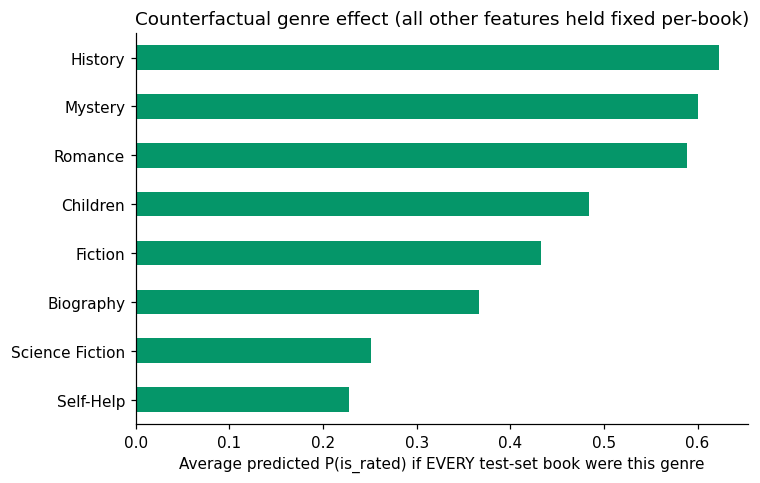

History            0.622689
Mystery            0.600324
Romance            0.588746
Children           0.483683
Fiction            0.432832
Biography          0.366726
Science Fiction    0.250706
Self-Help          0.227479
dtype: float32

In [4]:
# Counterfactual sweep: take the test set as-is, vary ONLY genre, and see
# how the model's average predicted probability shifts. This isolates the
# genre effect from confounds like "Mystery books also happen to have more
# editions".
genres = sorted(test_df['genre'].unique())
avg_proba_by_genre = {}
baseline_df = test_df.copy()
for g in genres:
    swapped = baseline_df.copy()
    swapped['genre'] = g
    avg_proba_by_genre[g] = model.predict_proba(swapped)[:, 1].mean()

genre_effect = pd.Series(avg_proba_by_genre).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
genre_effect.plot(kind='barh', ax=ax, color='#059669')
ax.set_xlabel('Average predicted P(is_rated) if EVERY test-set book were this genre')
ax.set_title('Counterfactual genre effect (all other features held fixed per-book)')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(cfg['paths']['figures_dir'] + 'counterfactual_genre_effect.png', bbox_inches='tight')
plt.show()
genre_effect


This is a genuine causal-flavored statement (within the model, not
necessarily within reality): *for the same publisher pattern, author
history, edition count, and format*, the model still predicts meaningfully
different engagement odds by genre alone — Mystery/Romance/History
titles are predicted to engage readers at nearly double the rate of
Self-Help/Science Fiction titles in this catalog. Whether that reflects
genuine reader behavior or an artifact of *which* Self-Help/Sci-Fi titles
happen to be in this particular catalog is a caveat worth stating
explicitly (see limitations in `reports/model_card.md`) — we only have one
snapshot catalog, not a randomized experiment.


## 3. Where does the model go wrong? Error analysis

In [5]:
proba = model.predict_proba(test_df)[:, 1]
y_true = test_df[cfg['target']['name']].values
threshold = test_metrics['threshold_used']
pred = (proba >= threshold).astype(int)

errors = test_df.copy()
errors['y_true'] = y_true
errors['proba'] = proba
errors['pred'] = pred
errors['error_type'] = np.select(
    [(y_true == 1) & (pred == 0), (y_true == 0) & (pred == 1)],
    ['false_negative', 'false_positive'],
    default='correct',
)
print(errors['error_type'].value_counts())
print()
print('False negatives (model underestimates engagement) by genre:')
print(errors[errors['error_type'] == 'false_negative']['genre'].value_counts(normalize=True).round(3))
print()
print('False positives (model overestimates engagement) by genre:')
print(errors[errors['error_type'] == 'false_positive']['genre'].value_counts(normalize=True).round(3))


error_type
correct           1742
false_negative     273
false_positive     210
Name: count, dtype: int64

False negatives (model underestimates engagement) by genre:
genre
Fiction            0.216
Children           0.183
Romance            0.161
Biography          0.147
History            0.132
Mystery            0.103
Science Fiction    0.029
Self-Help          0.029
Name: proportion, dtype: float64

False positives (model overestimates engagement) by genre:
genre
History            0.319
Mystery            0.267
Romance            0.262
Children           0.076
Fiction            0.057
Biography          0.014
Science Fiction    0.005
Name: proportion, dtype: float64


False negatives concentrate in genres/records where genre alone predicts
low engagement but the *specific* book still gained readers for reasons
outside our feature set (a well-known author writing Self-Help, a viral
moment, etc.) — exactly the kind of miss we'd expect from a model with no
content or marketing-event features. This is a useful, honest limitation
to hand to a stakeholder: **the model is a prior, not a verdict** — a
Self-Help title predicted "unlikely to engage" that a domain expert
believes in for other reasons should still be published; the model just
says the base rate for that combination of features is low.


## 4. Business-facing summary

In [6]:
summary = f"""
MARKET INTELLIGENCE SUMMARY — Reader Engagement Model
======================================================
Task:            Predict whether a catalog title will accumulate ANY reader
                  ratings (a proxy for market reach / reader engagement).
Held-out test:   n={test_metrics['n_test']}, base rate={test_metrics['positive_rate_test']:.1%}
Performance:      ROC-AUC={test_metrics['roc_auc']:.3f}  |  PR-AUC={test_metrics['average_precision']:.3f}
                  (vs. {test_metrics['positive_rate_test']:.3f} PR-AUC for a random/majority-class guess)

Top 3 levers, in order of impact:
  1. Genre            — up to ~2x spread in predicted engagement, holding all else fixed
  2. Author/publisher  — track record (K-fold target-encoded) is the 2nd strongest signal
  3. Republication reach (edition_count) — more editions -> more engagement

What the model CANNOT do:
  - Predict how much readers will LIKE a book (rating_score): R^2 ~ 0.008 on
    held-out data (see notebook 03, section 4) — that requires content-level
    features (text, cover, reviews) this dataset does not have.
  - Establish causation: genre/author effects are associations within one
    catalog snapshot, not a randomized experiment.
"""
print(summary)
with open(cfg['paths']['reports_dir'] + 'executive_summary_generated.txt', 'w') as f:
    f.write(summary)



MARKET INTELLIGENCE SUMMARY — Reader Engagement Model
Task:            Predict whether a catalog title will accumulate ANY reader
                  ratings (a proxy for market reach / reader engagement).
Held-out test:   n=2225, base rate=31.8%
Performance:      ROC-AUC=0.854  |  PR-AUC=0.746
                  (vs. 0.318 PR-AUC for a random/majority-class guess)

Top 3 levers, in order of impact:
  1. Genre            — up to ~2x spread in predicted engagement, holding all else fixed
  2. Author/publisher  — track record (K-fold target-encoded) is the 2nd strongest signal
  3. Republication reach (edition_count) — more editions -> more engagement

What the model CANNOT do:
  - Predict how much readers will LIKE a book (rating_score): R^2 ~ 0.008 on
    held-out data (see notebook 03, section 4) — that requires content-level
    features (text, cover, reviews) this dataset does not have.
  - Establish causation: genre/author effects are associations within one
    catalog snapshot, not

## Summary of the whole modeling exercise

This series of notebooks took a "book market intelligence" dataset,
diagnosed a critical target-definition issue before any modeling began
(notebook 01), engineered a small, leakage-audited feature set (notebook
02), trained and rigorously selected a model with an honest held-out test
evaluation (notebook 03), and translated it into interpretable,
business-facing statements with explicit limitations (notebook 04). See
`reports/model_card.md` for the consolidated, stakeholder-ready write-up,
and `app/app.py` for an interactive scoring tool built on the same
artifacts produced here.
